<h1>10 minutes to pandas</h1>

<p>This is a short introduction to pandas, geared mainly for new users.
You can see more complex recipes in the <a href="cookbook.html#cookbook">Cookbook</a>.</p>

<p>Customarily, we import as follows:</p>

In [24]:
import numpy as np
import pandas as pd

# <h2>Basic data structures in pandas</h2>

<p>Pandas provides two types of classes for handling data:</p>

<ol>
<li><dl>
<dt><a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.html#pandas.Series"><code>Series</code></a>: a one-dimensional labeled array holding data of any type</dt><dd><p>such as integers, strings, Python objects etc.</p>
</dd>
</dl>
</li>
<li><p><a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a>: a two-dimensional data structure that holds data like
a two-dimension array or a table with rows and columns.</p></li>
</ol>

# <h2>Object creation</h2>

<p>See the <a href="https://pandas.pydata.org/docs/user_guide/dsintro.html#dsintro">Intro to data structures section</a>.</p>

<p>Creating a <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.html#pandas.Series"><code>Series</code></a> by passing a list of values, letting pandas create a default <a href="https://pandas.pydata.org/docs/reference/api/pandas.RangeIndex.html#pandas.RangeIndex" title="pandas.RangeIndex"><code>RangeIndex</code></a>.</p>

In [25]:
s = pd.Series([1, 3, 5, np.nan, 6, 8])

In [26]:
s

,0
0,1.0
1,3.0
2,5.0
3,NaN
4,6.0
5,8.0


<p>Creating a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> by passing a NumPy array with a datetime index using <a href="https://pandas.pydata.org/docs/reference/api/pandas.date_range.html#pandas.date_range" title="pandas.date_range"><code>date_range()</code></a>
and labeled columns:</p>

In [27]:
dates = pd.date_range("20130101", periods=6)

In [28]:
dates

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[ns]', freq='D')

In [29]:
df = pd.DataFrame(np.random.randn(6, 4), index=dates, columns=list("ABCD"))

In [30]:
df

,A,B,C,D
2013-01-01,1.945123,1.191501,0.501364,-2.538422
2013-01-02,-1.529610,0.279182,0.678403,1.643361
2013-01-03,0.987561,0.164891,-0.038965,-0.063312
2013-01-04,0.355172,0.107204,0.053203,0.650684
2013-01-05,1.756706,-0.700755,0.311445,0.139044
2013-01-06,-1.893232,-1.357270,0.225809,-0.284451


<p>Creating a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> by passing a dictionary of objects where the keys are the column labels and the values are the column values.</p>

In [31]:
df2 = pd.DataFrame(
    {
        "A": 1.0,
        "B": pd.Timestamp("20130102"),
        "C": pd.Series(1, index=list(range(4)), dtype="float32"),
        "D": np.array([3] * 4, dtype="int32"),
        "E": pd.Categorical(["test", "train", "test", "train"]),
        "F": "foo",
    }
)

In [32]:
df2

,A,B,C,D,E,F
0,1.0,2013-01-02,1.0,3,test,foo
1,1.0,2013-01-02,1.0,3,train,foo
2,1.0,2013-01-02,1.0,3,test,foo
3,1.0,2013-01-02,1.0,3,train,foo


<p>The columns of the resulting <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> have different
<a href="https://pandas.pydata.org/docs/user_guide/basics.html#basics-dtypes">dtypes</a>:</p>

In [33]:
df2.dtypes

,0
A,float64
B,datetime64[s]
C,float32
D,int32
E,category
F,object


<p>If you’re using IPython, tab completion for column names (as well as public attributes) is automatically enabled.
Here’s a subset of the attributes that will be completed:</p>

<div class="highlight-ipython notranslate"><div class="highlight">
<pre>In [12]: df2<.&lt;TAB&gt;  # noqa: E225, E999
df2.A                  df2.bool
df2.abs                df2.boxplot
df2.add                df2.C
df2.add_prefix         df2.clip
df2.add_suffix         df2.columns
df2.align              df2.copy
df2.all                df2.count
df2.any                df2.combine
df2.append             df2.D
df2.apply              df2.describe
df2.applymap           df2.diff
df2.B                  df2.duplicated
</pre></div></div>

<p>As you can see, the columns <code>A</code>, <code>B</code>, <code>C</code>, and <code>D</code> are automatically tab completed.
<code>E</code> and <code>F</code> are there as well; the rest of the attributes have been truncated for brevity.</p>

# <h2>Viewing data</h2>

<p>See the <a href="https://pandas.pydata.org/docs/user_guide/basics.html#basics">Essentially basics functionality section</a>.</p>

<p>Use <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html#pandas.DataFrame.head" title="pandas.DataFrame.head"><code>DataFrame.head()</code></a> and <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.tail.html#pandas.DataFrame.tail" title="pandas.DataFrame.tail"><code>DataFrame.tail()</code></a> to view the top and bottom rows of the frame respectively:</p>

In [34]:
df.head()

,A,B,C,D
2013-01-01,1.945123,1.191501,0.501364,-2.538422
2013-01-02,-1.529610,0.279182,0.678403,1.643361
2013-01-03,0.987561,0.164891,-0.038965,-0.063312
2013-01-04,0.355172,0.107204,0.053203,0.650684
2013-01-05,1.756706,-0.700755,0.311445,0.139044


In [35]:
df.tail(3)

,A,B,C,D
2013-01-04,0.355172,0.107204,0.053203,0.650684
2013-01-05,1.756706,-0.700755,0.311445,0.139044
2013-01-06,-1.893232,-1.357270,0.225809,-0.284451


<p>Display the <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.index.html#pandas.DataFrame.index" title="pandas.DataFrame.index"><code>DataFrame.index</code></a> or <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.columns.html#pandas.DataFrame.columns" title="pandas.DataFrame.columns"><code>DataFrame.columns</code></a>:</p>

In [36]:
df.index

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[ns]', freq='D')

In [37]:
df.columns

Index(['A', 'B', 'C', 'D'], dtype='object')

<p>Return a NumPy representation of the underlying data with <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_numpy.html#pandas.DataFrame.to_numpy" title="pandas.DataFrame.to_numpy"><code>DataFrame.to_numpy()</code></a> without the index or column labels:</p>

In [38]:
df.to_numpy()

array([[ 1.94512345,  1.19150085,  0.50136361, -2.53842224],
       [-1.52961021,  0.27918202,  0.67840274,  1.64336094],
       [ 0.98756062,  0.16489095, -0.03896507, -0.06331235],
       [ 0.3551717 ,  0.10720354,  0.05320332,  0.65068442],
       [ 1.75670612, -0.70075532,  0.31144533,  0.1390437 ],
       [-1.89323159, -1.35727009,  0.22580916, -0.28445137]])

<div class="admonition note">
<p class="admonition-title">Note</p>
<p><strong>NumPy arrays have one dtype for the entire array while pandas DataFrames have one dtype per column</strong>.
When you call <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_numpy.html#pandas.DataFrame.to_numpy" title="pandas.DataFrame.to_numpy"><code>DataFrame.to_numpy()</code></a>, pandas will find the NumPy dtype that can hold <em>all</em> of the dtypes in the DataFrame.
If the common data type is <code>object</code>, <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_numpy.html#pandas.DataFrame.to_numpy" title="pandas.DataFrame.to_numpy"><code>DataFrame.to_numpy()</code></a> will require copying data.</p>

In [39]:
df2.dtypes

,0
A,float64
B,datetime64[s]
C,float32
D,int32
E,category
F,object


In [40]:
df2.to_numpy()

array([[1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 3, 'test', 'foo'],
       [1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 3, 'train', 'foo'],
       [1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 3, 'test', 'foo'],
       [1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 3, 'train', 'foo']],
      dtype=object)

<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html#pandas.DataFrame.describe" title="pandas.DataFrame.describe"><code>describe()</code></a> shows a quick statistic summary of your data:</p>

In [41]:
df.describe()

,A,B,C,D
count,6.000000,6.000000,6.000000,6.000000
mean,0.270287,-0.052541,0.288543,-0.075516
std,1.640527,0.877835,0.269959,1.388355
min,-1.893232,-1.357270,-0.038965,-2.538422
25%,-1.058415,-0.498766,0.096355,-0.229167
50%,0.671366,0.136047,0.268627,0.037866
75%,1.564420,0.250609,0.453884,0.522774
max,1.945123,1.191501,0.678403,1.643361


<p>Transposing your data:</p>

In [42]:
df.T

,2013-01-01,2013-01-02,2013-01-03,2013-01-04,2013-01-05,2013-01-06
A,1.945123,-1.529610,0.987561,0.355172,1.756706,-1.893232
B,1.191501,0.279182,0.164891,0.107204,-0.700755,-1.357270
C,0.501364,0.678403,-0.038965,0.053203,0.311445,0.225809
D,-2.538422,1.643361,-0.063312,0.650684,0.139044,-0.284451


<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_index.html#pandas.DataFrame.sort_index" title="pandas.DataFrame.sort_index"><code>DataFrame.sort_index()</code></a> sorts by an axis:</p>

In [43]:
df.sort_index(axis=1, ascending=False)

,D,C,B,A
2013-01-01,-2.538422,0.501364,1.191501,1.945123
2013-01-02,1.643361,0.678403,0.279182,-1.529610
2013-01-03,-0.063312,-0.038965,0.164891,0.987561
2013-01-04,0.650684,0.053203,0.107204,0.355172
2013-01-05,0.139044,0.311445,-0.700755,1.756706
2013-01-06,-0.284451,0.225809,-1.357270,-1.893232


<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html#pandas.DataFrame.sort_values" title="pandas.DataFrame.sort_values"><code>DataFrame.sort_values()</code></a> sorts by values:</p>

In [44]:
df.sort_values(by="B")

,A,B,C,D
2013-01-06,-1.893232,-1.357270,0.225809,-0.284451
2013-01-05,1.756706,-0.700755,0.311445,0.139044
2013-01-04,0.355172,0.107204,0.053203,0.650684
2013-01-03,0.987561,0.164891,-0.038965,-0.063312
2013-01-02,-1.529610,0.279182,0.678403,1.643361
2013-01-01,1.945123,1.191501,0.501364,-2.538422


# <h2>Selection</h2>

<div class="admonition note">
<p class="admonition-title">Note</p>
<p>While standard Python / NumPy expressions for selecting and setting are intuitive and come in handy for interactive work, for production code, we recommend the optimized pandas data access methods, <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.at.html#pandas.DataFrame.at" title="pandas.DataFrame.at"><code>DataFrame.at()</code></a>, <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iat.html#pandas.DataFrame.iat" title="pandas.DataFrame.iat"><code>DataFrame.iat()</code></a>,
<a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html#pandas.DataFrame.loc" title="pandas.DataFrame.loc"><code>DataFrame.loc()</code></a> and <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iloc.html#pandas.DataFrame.iloc" title="pandas.DataFrame.iloc"><code>DataFrame.iloc()</code></a>.</p></div>

<p>See the indexing documentation <a href="https://pandas.pydata.org/docs/user_guide/indexing.html#indexing">Indexing and Selecting Data</a> and <a href="https://pandas.pydata.org/docs/user_guide/advanced.html#advanced">MultiIndex / Advanced Indexing</a>.</p>

## <h3>Getitem (<code>[]</code>)</h3>

<p>For a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a>, passing a single label selects a columns and yields a <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.html#pandas.Series"><code>Series</code></a> equivalent to <code>df.A</code>:</p>

In [45]:
df["A"]

,A
2013-01-01,1.945123
2013-01-02,-1.529610
2013-01-03,0.987561
2013-01-04,0.355172
2013-01-05,1.756706
2013-01-06,-1.893232


<p>For a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a>, passing a slice <code>:</code> selects matching rows:</p>

In [46]:
df[0:3]

,A,B,C,D
2013-01-01,1.945123,1.191501,0.501364,-2.538422
2013-01-02,-1.529610,0.279182,0.678403,1.643361
2013-01-03,0.987561,0.164891,-0.038965,-0.063312


In [47]:
df["20130102":"20130104"]

,A,B,C,D
2013-01-02,-1.529610,0.279182,0.678403,1.643361
2013-01-03,0.987561,0.164891,-0.038965,-0.063312
2013-01-04,0.355172,0.107204,0.053203,0.650684


## <h3>Selection by label</h3>

<p>See more in <a href="https://pandas.pydata.org/docs/user_guide/indexing.html#indexing-label">Selection by Label</a> using <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html#pandas.DataFrame.loc" title="pandas.DataFrame.loc"><code>DataFrame.loc()</code></a> or <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.at.html#pandas.DataFrame.at" title="pandas.DataFrame.at"><code>DataFrame.at()</code></a>.</p>

<p>Selecting a row matching a label:</p>

In [48]:
df.loc[dates[0]]

,2013-01-01
A,1.945123
B,1.191501
C,0.501364
D,-2.538422


<p>Selecting all rows (<code>:</code>) with a select column labels:</p>

In [49]:
df.loc[:, ["A", "B"]]

,A,B
2013-01-01,1.945123,1.191501
2013-01-02,-1.529610,0.279182
2013-01-03,0.987561,0.164891
2013-01-04,0.355172,0.107204
2013-01-05,1.756706,-0.700755
2013-01-06,-1.893232,-1.357270


<p>For label slicing, both endpoints are <em>included</em>:</p>

In [50]:
df.loc["20130102":"20130104", ["A", "B"]]

,A,B
2013-01-02,-1.529610,0.279182
2013-01-03,0.987561,0.164891
2013-01-04,0.355172,0.107204


<p>Selecting a single row and column label returns a scalar:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell19"><span></span><span class="gp">In [30]: </span><span class="n">df</span><span class="o">.</span><span class="n">loc</span><span class="p">[</span><span class="n">dates</span><span class="p">[</span><span class="mi">0</span><span class="p">],</span> <span class="s2">"A"</span><span class="p">]</span>
<span class="gh">Out[30]: </span>0.4691122999071863</span>
</pre>
</div>
</div>

<p>For getting fast access to a scalar (equivalent to the prior method):</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell20"><span></span><span class="gp">In [31]: </span><span class="n">df</span><span class="o">.</span><span class="n">at</span><span class="p">[</span><span class="n">dates</span><span class="p">[</span><span class="mi">0</span><span class="p">],</span> <span class="s2">"A"</span><span class="p">]</span>
<span class="gh">Out[31]: </span>0.4691122999071863</span>
</pre>
</div>
</div>

## <h3>Selection by position</h3>

<p>See more in <a href="https://pandas.pydata.org/docs/user_guide/indexing.html#indexing-integer">Selection by Position</a> using <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iloc.html#pandas.DataFrame.iloc" title="pandas.DataFrame.iloc"><code>DataFrame.iloc()</code></a> or <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iat.html#pandas.DataFrame.iat" title="pandas.DataFrame.iat"><code>DataFrame.iat()</code></a>.</p>

<p>Select via the position of the passed integers:</p>

In [51]:
df.iloc[3]

,2013-01-04
A,0.355172
B,0.107204
C,0.053203
D,0.650684


<p>Integer slices acts similar to NumPy/Python:</p>

In [52]:
df.iloc[3:5, 0:2]

,A,B
2013-01-04,0.355172,0.107204
2013-01-05,1.756706,-0.700755


<p>Lists of integer position locations:</p>

In [53]:
df.iloc[[1, 2, 4], [0, 2]]

,A,C
2013-01-02,-1.529610,0.678403
2013-01-03,0.987561,-0.038965
2013-01-05,1.756706,0.311445


<p>For slicing rows explicitly:</p>

In [54]:
df.iloc[1:3, :]

,A,B,C,D
2013-01-02,-1.529610,0.279182,0.678403,1.643361
2013-01-03,0.987561,0.164891,-0.038965,-0.063312


<p>For slicing columns explicitly:</p>

In [55]:
df.iloc[:, 1:3]

,B,C
2013-01-01,1.191501,0.501364
2013-01-02,0.279182,0.678403
2013-01-03,0.164891,-0.038965
2013-01-04,0.107204,0.053203
2013-01-05,-0.700755,0.311445
2013-01-06,-1.357270,0.225809


<p>For getting a value explicitly:</p>

In [56]:
df.iloc[1, 1]

np.float64(0.2791820183861641)

<p>For getting fast access to a scalar (equivalent to the prior method):</p>

In [57]:
df.iat[1, 1]

np.float64(0.2791820183861641)

## <h3>Boolean indexing</h3>

<p>Select rows where <code>df.A</code> is greater than <code>0</code>.</p>

In [58]:
df[df["A"] > 0]

,A,B,C,D
2013-01-01,1.945123,1.191501,0.501364,-2.538422
2013-01-03,0.987561,0.164891,-0.038965,-0.063312
2013-01-04,0.355172,0.107204,0.053203,0.650684
2013-01-05,1.756706,-0.700755,0.311445,0.139044


<p>Selecting values from a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> where a boolean condition is met:</p>

In [59]:
df[df > 0]

,A,B,C,D
2013-01-01,1.945123,1.191501,0.501364,NaN
2013-01-02,NaN,0.279182,0.678403,1.643361
2013-01-03,0.987561,0.164891,NaN,NaN
2013-01-04,0.355172,0.107204,0.053203,0.650684
2013-01-05,1.756706,NaN,0.311445,0.139044
2013-01-06,NaN,NaN,0.225809,NaN


<p>Using <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.isin.html#pandas.Series.isin" title="pandas.Series.isin"><code>isin()</code></a> method for filtering:</p>

In [60]:
df2 = df.copy()

In [61]:
df2["E"] = ["one", "one", "two", "three", "four", "three"]

In [62]:
df2

,A,B,C,D,E
2013-01-01,1.945123,1.191501,0.501364,-2.538422,one
2013-01-02,-1.529610,0.279182,0.678403,1.643361,one
2013-01-03,0.987561,0.164891,-0.038965,-0.063312,two
2013-01-04,0.355172,0.107204,0.053203,0.650684,three
2013-01-05,1.756706,-0.700755,0.311445,0.139044,four
2013-01-06,-1.893232,-1.357270,0.225809,-0.284451,three


In [63]:
df2[df2["E"].isin(["two", "four"])]

,A,B,C,D,E
2013-01-03,0.987561,0.164891,-0.038965,-0.063312,two
2013-01-05,1.756706,-0.700755,0.311445,0.139044,four


## <h3>Setting</h3>

<p>Setting a new column automatically aligns the data by the indexes:</p>

In [64]:
s1 = pd.Series([1, 2, 3, 4, 5, 6], index=pd.date_range("20130102", periods=6))

In [65]:
s1

,0
2013-01-02,1
2013-01-03,2
2013-01-04,3
2013-01-05,4
2013-01-06,5
2013-01-07,6


In [66]:
df["F"] = s1

<p>Setting values by label:</p>

In [67]:
df.at[dates[0], "A"] = 0

<p>Setting values by position:</p>

In [68]:
df.iat[0, 1] = 0

<p>Setting by assigning with a NumPy array:</p>

In [69]:
df.loc[:, "D"] = np.array([5] * len(df))

<p>The result of the prior setting operations:</p>

In [70]:
df

,A,B,C,D,F
2013-01-01,0.000000,0.000000,0.501364,5.0,NaN
2013-01-02,-1.529610,0.279182,0.678403,5.0,1.0
2013-01-03,0.987561,0.164891,-0.038965,5.0,2.0
2013-01-04,0.355172,0.107204,0.053203,5.0,3.0
2013-01-05,1.756706,-0.700755,0.311445,5.0,4.0
2013-01-06,-1.893232,-1.357270,0.225809,5.0,5.0


<p>A <code>where</code> operation with setting:</p>

In [71]:
df2 = df.copy()

In [72]:
df2[df2 > 0] = -df2

In [73]:
df2

,A,B,C,D,F
2013-01-01,0.000000,0.000000,-0.501364,-5.0,NaN
2013-01-02,-1.529610,-0.279182,-0.678403,-5.0,-1.0
2013-01-03,-0.987561,-0.164891,-0.038965,-5.0,-2.0
2013-01-04,-0.355172,-0.107204,-0.053203,-5.0,-3.0
2013-01-05,-1.756706,-0.700755,-0.311445,-5.0,-4.0
2013-01-06,-1.893232,-1.357270,-0.225809,-5.0,-5.0


# <h2>Missing data</h2>

<p>For NumPy data types, <code>np.nan</code> represents missing data. It is by default not included in computations.
See the <a href="https://pandas.pydata.org/docs/user_guide/missing_data.html#missing-data">Missing Data section</a>.</p>

<p>Reindexing allows you to change/add/delete the index on a specified axis. This returns a copy of the data:</p>

In [74]:
df1 = df.reindex(index=dates[0:4], columns=list(df.columns) + ["E"])

In [75]:
df1.loc[dates[0] : dates[1], "E"] = 1

In [76]:
df1

,A,B,C,D,F,E
2013-01-01,0.000000,0.000000,0.501364,5.0,NaN,1.0
2013-01-02,-1.529610,0.279182,0.678403,5.0,1.0,1.0
2013-01-03,0.987561,0.164891,-0.038965,5.0,2.0,NaN
2013-01-04,0.355172,0.107204,0.053203,5.0,3.0,NaN


<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html#pandas.DataFrame.dropna" title="pandas.DataFrame.dropna"><code>DataFrame.dropna()</code></a> drops any rows that have missing data:</p>

In [77]:
df1.dropna(how="any")

,A,B,C,D,F,E
2013-01-02,-1.52961,0.279182,0.678403,5.0,1.0,1.0


<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell38"><span></span><span class="gp">In [58]: </span><span class="n">df1</span><span class="o">.</span><span class="n">dropna</span><span class="p">(</span><span class="n">how</span><span class="o">=</span><span class="s2">"any"</span><span class="p">)</span>
<span class="gh">Out[58]: </span>
                   A         B         C    D    F    E</span>
2013-01-02  1.212112 -0.173215  0.119209  5.0  1.0  1.0</span>
</pre>
</div>
</div>

<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html#pandas.DataFrame.fillna" title="pandas.DataFrame.fillna"><code>DataFrame.fillna()</code></a> fills missing data:</p>

In [78]:
 df1.fillna(value=5)

,A,B,C,D,F,E
2013-01-01,0.000000,0.000000,0.501364,5.0,5.0,1.0
2013-01-02,-1.529610,0.279182,0.678403,5.0,1.0,1.0
2013-01-03,0.987561,0.164891,-0.038965,5.0,2.0,5.0
2013-01-04,0.355172,0.107204,0.053203,5.0,3.0,5.0


<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.isna.html#pandas.isna" title="pandas.isna"><code>isna()</code></a> gets the boolean mask where values are <code>nan</code>:</p>

In [79]:
pd.isna(df1)

,A,B,C,D,F,E
2013-01-01,False,False,False,False,True,False
2013-01-02,False,False,False,False,False,False
2013-01-03,False,False,False,False,False,True
2013-01-04,False,False,False,False,False,True


# <h2>Operations</h2>

<p>See the <a href="https://pandas.pydata.org/docs/user_guide/basics.html#basics-binop">Basic section on Binary Ops</a>.</p>

## <h3>Stats</h3>

<p>Operations in general <em>exclude</em> missing data.</p>

<p>Calculate the mean value for each column:</p>

In [80]:
df.mean()

,0
A,-0.053901
B,-0.251125
C,0.288543
D,5.000000
F,3.000000


<p>Calculate the mean value for each row:</p>

In [81]:
df.mean(axis=1)

,0
2013-01-01,1.375341
2013-01-02,1.085595
2013-01-03,1.622697
2013-01-04,1.703116
2013-01-05,2.073479
2013-01-06,1.395061


<p>Operating with another <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.html#pandas.Series"><code>Series</span></code></a> or <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> with a different index or column will align the result with the union of the index or column labels.
In addition, pandas automatically broadcasts along the specified dimension and will fill unaligned labels with <code>np.nan</code>.</p>

In [84]:
s = pd.Series([1, 3, 5, np.nan, 6, 8], index=dates).shift(2)

In [85]:
s

,0
2013-01-01,NaN
2013-01-02,NaN
2013-01-03,1.0
2013-01-04,3.0
2013-01-05,5.0
2013-01-06,NaN


In [86]:
df.sub(s, axis="index")

,A,B,C,D,F
2013-01-01,NaN,NaN,NaN,NaN,NaN
2013-01-02,NaN,NaN,NaN,NaN,NaN
2013-01-03,-0.012439,-0.835109,-1.038965,4.0,1.0
2013-01-04,-2.644828,-2.892796,-2.946797,2.0,0.0
2013-01-05,-3.243294,-5.700755,-4.688555,0.0,-1.0
2013-01-06,NaN,NaN,NaN,NaN,NaN


## <h3>User defined functions</h3>

<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.agg.html#pandas.DataFrame.agg" title="pandas.DataFrame.agg"><code>DataFrame.agg()</code></a> and <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.transform.html#pandas.DataFrame.transform" title="pandas.DataFrame.transform"><code>DataFrame.transform()</code></a> applies a user defined function
that reduces or broadcasts its result respectively.</p>

In [89]:
df.agg(lambda x: np.mean(x) * 5.6)

,0
A,-0.301843
B,-1.406299
C,1.615842
D,28.000000
F,16.800000


In [93]:
df.transform(lambda x: x * 101.2)

,A,B,C,D,F
2013-01-01,0.000000,0.000000,50.737997,506.0,NaN
2013-01-02,-154.796553,28.253220,68.654357,506.0,101.2
2013-01-03,99.941135,16.686965,-3.943265,506.0,202.4
2013-01-04,35.943376,10.848998,5.384176,506.0,303.6
2013-01-05,177.778659,-70.916438,31.518268,506.0,404.8
2013-01-06,-191.595036,-137.355734,22.851887,506.0,506.0


## <h3>Value Counts</h3>

<p>See more at <a href="https://pandas.pydata.org/docs/user_guide/basics.html#basics-discretization">Histogramming and Discretization</a>.</p>

In [94]:
s = pd.Series(np.random.randint(0, 7, size=10))

In [95]:
s

,0
0,5
1,6
2,6
3,6
4,0
5,3
6,5
7,0
8,5
9,5


In [96]:
s.value_counts()

,count
5,4
6,3
0,2
3,1


## <h3>String Methods</h3>

<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.html#pandas.Series"><code>Series</code></a> is equipped with a set of string processing methods in the <code>str</code> attribute that make it easy to operate on each element of the array, as in the code snippet below. See more at <a href="https://pandas.pydata.org/docs/user_guide/text.html#text-string-methods">Vectorized String Methods</a>.</p>

In [97]:
s = pd.Series(["A", "B", "C", "Aaba", "Baca", np.nan, "CABA", "dog", "cat"])

In [98]:
s.str.lower()

,0
0,a
1,b
2,c
3,aaba
4,baca
5,NaN
6,caba
7,dog
8,cat


# <h2>Merge</h2>

## <h3>Concat</h3>

<p>pandas provides various facilities for easily combining together <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.html#pandas.Series"><code>Series</code></a> and
<a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> objects with various kinds of set logic for the indexes
and relational algebra functionality in the case of join / merge-type
operations.</p>

<p>See the <a href="https://pandas.pydata.org/docs/user_guide/merging.html#merging">Merging section</a>.</p>

<p>Concatenating pandas objects together row-wise with <a href="https://pandas.pydata.org/docs/reference/api/pandas.concat.html#pandas.concat" title="pandas.concat"><code>concat()</code></a>:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell47"><span></span><span class="gp">In [73]: </span><span class="n">df</span> <span class="o">=</span> <span class="n">pd</span><span class="o">.</span><span class="n">DataFrame</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">random</span><span class="o">.</span><span class="n">randn</span><span class="p">(</span><span class="mi">10</span><span class="p">,</span> <span class="mi">4</span><span class="p">))</span>

<span class="gp">In [74]: </span><span class="n">df</span>
<span class="gh">Out[74]: </span>
          0         1         2         3</span>
0 -0.548702  1.467327 -1.015962 -0.483075</span>
1  1.637550 -1.217659 -0.291519 -1.745505</span>
2 -0.263952  0.991460 -0.919069  0.266046</span>
3 -0.709661  1.669052  1.037882 -1.705775</span>
4 -0.919854 -0.042379  1.247642 -0.009920</span>
5  0.290213  0.495767  0.362949  1.548106</span>
6 -1.131345 -0.089329  0.337863 -0.945867</span>
7 -0.932132  1.956030  0.017587 -0.016692</span>
8 -0.575247  0.254161 -1.143704  0.215897</span>
9  1.193555 -0.077118 -0.408530 -0.862495</span>

# break it into pieces</span>
<span class="gp">In [75]: </span><span class="n">pieces</span> <span class="o">=</span> <span class="p">[</span><span class="n">df</span><span class="p">[:</span><span class="mi">3</span><span class="p">],</span> <span class="n">df</span><span class="p">[</span><span class="mi">3</span><span class="p">:</span><span class="mi">7</span><span class="p">],</span> <span class="n">df</span><span class="p">[</span><span class="mi">7</span><span class="p">:]]</span>

<span class="gp">In [76]: </span><span class="n">pd</span><span class="o">.</span><span class="n">concat</span><span class="p">(</span><span class="n">pieces</span><span class="p">)</span>
<span class="gh">Out[76]: </span>
          0         1         2         3</span>
0 -0.548702  1.467327 -1.015962 -0.483075</span>
1  1.637550 -1.217659 -0.291519 -1.745505</span>
2 -0.263952  0.991460 -0.919069  0.266046</span>
3 -0.709661  1.669052  1.037882 -1.705775</span>
4 -0.919854 -0.042379  1.247642 -0.009920</span>
5  0.290213  0.495767  0.362949  1.548106</span>
6 -1.131345 -0.089329  0.337863 -0.945867</span>
7 -0.932132  1.956030  0.017587 -0.016692</span>
8 -0.575247  0.254161 -1.143704  0.215897</span>
9  1.193555 -0.077118 -0.408530 -0.862495</span>
</pre>
</div>
</div>

<div class="admonition note">
<p class="admonition-title">Note</p>
<p>Adding a column to a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> is relatively fast. However, adding a row requires a copy, and may be expensive.
We recommend passing a pre-built list of records to the <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> constructor instead of building a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> by iteratively appending records to it.</p>
</div>

## <h3>Join</h3>

<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.merge.html#pandas.merge"><code>merge()</code></a> enables SQL style join types along specific columns. See the <a href="https://pandas.pydata.org/docs/user_guide/merging.html#merging-join">Database style joining</a> section.</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell48"><span></span><span class="gp">In [77]: </span><span class="n">left</span> <span class="o">=</span> <span class="n">pd</span><span class="o">.</span><span class="n">DataFrame</span><span class="p">({</span><span class="s2">"key"</span><span class="p">:</span> <span class="p">[</span><span class="s2">"foo"</span><span class="p">,</span> <span class="s2">"foo"</span><span class="p">],</span> <span class="s2">"lval"</span><span class="p">:</span> <span class="p">[</span><span class="mi">1</span><span class="p">,</span> <span class="mi">2</span><span class="p">]})</span>

<span class="gp">In [78]: </span><span class="n">right</span> <span class="o">=</span> <span class="n">pd</span><span class="o">.</span><span class="n">DataFrame</span><span class="p">({</span><span class="s2">"key"</span><span class="p">:</span> <span class="p">[</span><span class="s2">"foo"</span><span class="p">,</span> <span class="s2">"foo"</span><span class="p">],</span> <span class="s2">"rval"</span><span class="p">:</span> <span class="p">[</span><span class="mi">4</span><span class="p">,</span> <span class="mi">5</span><span class="p">]})</span>

<span class="gp">In [79]: </span><span class="n">left</span>
<span class="gh">Out[79]: </span>
   key  lval</span>
0  foo     1</span>
1  foo     2</span>

<span class="gp">In [80]: </span><span class="n">right</span>
<span class="gh">Out[80]: </span>
   key  rval</span>
0  foo     4</span>
1  foo     5</span>

<span class="gp">In [81]: </span><span class="n">pd</span><span class="o">.</span><span class="n">merge</span><span class="p">(</span><span class="n">left</span><span class="p">,</span> <span class="n">right</span><span class="p">,</span> <span class="n">on</span><span class="o">=</span><span class="s2">"key"</span><span class="p">)</span>
<span class="gh">Out[81]: </span>
   key  lval  rval</span>
0  foo     1     4</span>
1  foo     1     5</span>
2  foo     2     4</span>
3  foo     2     5</span>
</pre>
</div>
</div>

<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.merge.html#pandas.merge" title="pandas.merge"><code>merge()</code></a> on unique keys:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell49"><span></span><span class="gp">In [82]: </span><span class="n">left</span> <span class="o">=</span> <span class="n">pd</span><span class="o">.</span><span class="n">DataFrame</span><span class="p">({</span><span class="s2">"key"</span><span class="p">:</span> <span class="p">[</span><span class="s2">"foo"</span><span class="p">,</span> <span class="s2">"bar"</span><span class="p">],</span> <span class="s2">"lval"</span><span class="p">:</span> <span class="p">[</span><span class="mi">1</span><span class="p">,</span> <span class="mi">2</span><span class="p">]})</span>

<span class="gp">In [83]: </span><span class="n">right</span> <span class="o">=</span> <span class="n">pd</span><span class="o">.</span><span class="n">DataFrame</span><span class="p">({</span><span class="s2">"key"</span><span class="p">:</span> <span class="p">[</span><span class="s2">"foo"</span><span class="p">,</span> <span class="s2">"bar"</span><span class="p">],</span> <span class="s2">"rval"</span><span class="p">:</span> <span class="p">[</span><span class="mi">4</span><span class="p">,</span> <span class="mi">5</span><span class="p">]})</span>

<span class="gp">In [84]: </span><span class="n">left</span>
<span class="gh">Out[84]: </span>
   key  lval</span>
0  foo     1</span>
1  bar     2</span>

<span class="gp">In [85]: </span><span class="n">right</span>
<span class="gh">Out[85]: </span>
   key  rval</span>
0  foo     4</span>
1  bar     5</span>

<span class="gp">In [86]: </span><span class="n">pd</span><span class="o">.</span><span class="n">merge</span><span class="p">(</span><span class="n">left</span><span class="p">,</span> <span class="n">right</span><span class="p">,</span> <span class="n">on</span><span class="o">=</span><span class="s2">"key"</span><span class="p">)</span>
<span class="gh">Out[86]: </span>
   key  lval  rval</span>
0  foo     1     4</span>
1  bar     2     5</span>
</pre>
</div>
</div>

# <h2>Grouping</h2>

<p>By “group by” we are referring to a process involving one or more of the following steps:</p>

<ul>
<li><p><strong>Splitting</strong> the data into groups based on some criteria</p></li>
<li><p><strong>Applying</strong> a function to each group independently</p></li>
<li><p><strong>Combining</strong> the results into a data structure</p></li>
</ul>

<p>See the <a href="https://pandas.pydata.org/docs/user_guide/groupby.html#groupby">Grouping section</a>.</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell50"><span></span><span class="gp">In [87]: </span><span class="n">df</span> <span class="o">=</span> <span class="n">pd</span><span class="o">.</span><span class="n">DataFrame</span><span class="p">(</span>
<span class="gp">   ....: </span>    <span class="p">{</span>
<span class="gp">   ....: </span>        <span class="s2">"A"</span><span class="p">:</span> <span class="p">[</span><span class="s2">"foo"</span><span class="p">,</span> <span class="s2">"bar"</span><span class="p">,</span> <span class="s2">"foo"</span><span class="p">,</span> <span class="s2">"bar"</span><span class="p">,</span> <span class="s2">"foo"</span><span class="p">,</span> <span class="s2">"bar"</span><span class="p">,</span> <span class="s2">"foo"</span><span class="p">,</span> <span class="s2">"foo"</span><span class="p">],</span>
<span class="gp">   ....: </span>        <span class="s2">"B"</span><span class="p">:</span> <span class="p">[</span><span class="s2">"one"</span><span class="p">,</span> <span class="s2">"one"</span><span class="p">,</span> <span class="s2">"two"</span><span class="p">,</span> <span class="s2">"three"</span><span class="p">,</span> <span class="s2">"two"</span><span class="p">,</span> <span class="s2">"two"</span><span class="p">,</span> <span class="s2">"one"</span><span class="p">,</span> <span class="s2">"three"</span><span class="p">],</span>
<span class="gp">   ....: </span>        <span class="s2">"C"</span><span class="p">:</span> <span class="n">np</span><span class="o">.</span><span class="n">random</span><span class="o">.</span><span class="n">randn</span><span class="p">(</span><span class="mi">8</span><span class="p">),</span>
<span class="gp">   ....: </span>        <span class="s2">"D"</span><span class="p">:</span> <span class="n">np</span><span class="o">.</span><span class="n">random</span><span class="o">.</span><span class="n">randn</span><span class="p">(</span><span class="mi">8</span><span class="p">),</span>
<span class="gp">   ....: </span>    <span class="p">}</span>
<span class="gp">   ....: </span><span class="p">)</span>
<span class="gp">   ....: </span>

<span class="gp">In [88]: </span><span class="n">df</span>
<span class="gh">Out[88]: </span>
     A      B         C         D</span>
0  foo    one  1.346061 -1.577585</span>
1  bar    one  1.511763  0.396823</span>
2  foo    two  1.627081 -0.105381</span>
3  bar  three -0.990582 -0.532532</span>
4  foo    two -0.441652  1.453749</span>
5  bar    two  1.211526  1.208843</span>
6  foo    one  0.268520 -0.080952</span>
7  foo  three  0.024580 -0.264610</span>
</pre>
</div>
</div>

<p>Grouping by a column label, selecting column labels, and then applying the <a href="https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.sum.html#pandas.core.groupby.DataFrameGroupBy.sum" title="pandas.core.groupby.DataFrameGroupBy.sum"><code>DataFrameGroupBy.sum()</code></a> function to the resulting groups:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell51"><span></span><span class="gp">In [89]: </span><span class="n">df</span><span class="o">.</span><span class="n">groupby</span><span class="p">(</span><span class="s2">"A"</span><span class="p">)[[</span><span class="s2">"C"</span><span class="p">,</span> <span class="s2">"D"</span><span class="p">]]</span><span class="o">.</span><span class="n">sum</span><span class="p">()</span>
<span class="gh">Out[89]: </span>
            C         D</span>
A                      </span>
bar  1.732707  1.073134</span>
foo  2.824590 -0.574779</span>
</pre>
</div>
</div>

<p>Grouping by multiple columns label forms <a href="https://pandas.pydata.org/docs/reference/api/pandas.MultiIndex.html#pandas.MultiIndex" title="pandas.MultiIndex"><code>MultiIndex</code></a>.</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell52"><span></span><span class="gp">In [90]: </span><span class="n">df</span><span class="o">.</span><span class="n">groupby</span><span class="p">([</span><span class="s2">"A"</span><span class="p">,</span> <span class="s2">"B"</span><span class="p">])</span><span class="o">.</span><span class="n">sum</span><span class="p">()</span>
<span class="gh">Out[90]: </span>
                  C         D</span>
A   B                        </span>
bar one    1.511763  0.396823</span>
    three -0.990582 -0.532532</span>
    two    1.211526  1.208843</span>
foo one    1.614581 -1.658537</span>
    three  0.024580 -0.264610</span>
    two    1.185429  1.348368</span>
</pre>
</div>
</div>

# <h2>Reshaping</h2>

<p>See the sections on <a href="https://pandas.pydata.org/docs/user_guide/advanced.html#advanced-hierarchical">Hierarchical Indexing</a> and <a href="https://pandas.pydata.org/docs/user_guide/reshaping.html#reshaping-stacking">Reshaping</a>.</p>

## <h3>Stack</h3>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell53"><span></span><span class="gp">In [91]: </span><span class="n">arrays</span> <span class="o">=</span> <span class="p">[</span>
<span class="gp">   ....: </span>   <span class="p">[</span><span class="s2">"bar"</span><span class="p">,</span> <span class="s2">"bar"</span><span class="p">,</span> <span class="s2">"baz"</span><span class="p">,</span> <span class="s2">"baz"</span><span class="p">,</span> <span class="s2">"foo"</span><span class="p">,</span> <span class="s2">"foo"</span><span class="p">,</span> <span class="s2">"qux"</span><span class="p">,</span> <span class="s2">"qux"</span><span class="p">],</span>
<span class="gp">   ....: </span>   <span class="p">[</span><span class="s2">"one"</span><span class="p">,</span> <span class="s2">"two"</span><span class="p">,</span> <span class="s2">"one"</span><span class="p">,</span> <span class="s2">"two"</span><span class="p">,</span> <span class="s2">"one"</span><span class="p">,</span> <span class="s2">"two"</span><span class="p">,</span> <span class="s2">"one"</span><span class="p">,</span> <span class="s2">"two"</span><span class="p">],</span>
<span class="gp">   ....: </span><span class="p">]</span>
<span class="gp">   ....: </span>

<span class="gp">In [92]: </span><span class="n">index</span> <span class="o">=</span> <span class="n">pd</span><span class="o">.</span><span class="n">MultiIndex</span><span class="o">.</span><span class="n">from_arrays</span><span class="p">(</span><span class="n">arrays</span><span class="p">,</span> <span class="n">names</span><span class="o">=</span><span class="p">[</span><span class="s2">"first"</span><span class="p">,</span> <span class="s2">"second"</span><span class="p">])</span>

<span class="gp">In [93]: </span><span class="n">df</span> <span class="o">=</span> <span class="n">pd</span><span class="o">.</span><span class="n">DataFrame</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">random</span><span class="o">.</span><span class="n">randn</span><span class="p">(</span><span class="mi">8</span><span class="p">,</span> <span class="mi">2</span><span class="p">),</span> <span class="n">index</span><span class="o">=</span><span class="n">index</span><span class="p">,</span> <span class="n">columns</span><span class="o">=</span><span class="p">[</span><span class="s2">"A"</span><span class="p">,</span> <span class="s2">"B"</span><span class="p">])</span>

<span class="gp">In [94]: </span><span class="n">df2</span> <span class="o">=</span> <span class="n">df</span><span class="p">[:</span><span class="mi">4</span><span class="p">]</span>

<span class="gp">In [95]: </span><span class="n">df2</span>
<span class="gh">Out[95]: </span>
                     A         B</span>
first second                    </span>
bar   one    -0.727965 -0.589346</span>
      two     0.339969 -0.693205</span>
baz   one    -0.339355  0.593616</span>
      two     0.884345  1.591431</span>
</pre>
</div>
</div>

<p>The <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.stack.html#pandas.DataFrame.stack" title="pandas.DataFrame.stack"><code>stack()</code></a> method “compresses” a level in the DataFrame’s
columns:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell54"><span></span><span class="gp">In [96]: </span><span class="n">stacked</span> <span class="o">=</span> <span class="n">df2</span><span class="o">.</span><span class="n">stack</span><span class="p">(</span><span class="n">future_stack</span><span class="o">=</span><span class="kc">True</span><span class="p">)</span>

<span class="gp">In [97]: </span><span class="n">stacked</span>
<span class="gh">Out[97]: </span>
first  second   </span>
bar    one     A   -0.727965</span>
               B   -0.589346</span>
       two     A    0.339969</span>
               B   -0.693205</span>
baz    one     A   -0.339355</span>
               B    0.593616</span>
       two     A    0.884345</span>
               B    1.591431</span>
dtype: float64</span>
</pre>
</div>
</div>

<p>With a “stacked” DataFrame or Series (having a <a href="https://pandas.pydata.org/docs/reference/api/pandas.MultiIndex.html#pandas.MultiIndex" title="pandas.MultiIndex"><code>MultiIndex</code></a> as the <code>index</code>), the inverse operation of <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.stack.html#pandas.DataFrame.stack" title="pandas.DataFrame.stack"><code>stack()</code></a> is <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.unstack.html#pandas.DataFrame.unstack" title="pandas.DataFrame.unstack"><code>unstack()</code></a>, which by default unstacks the <strong>last level</strong>:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell55"><span></span><span class="gp">In [98]: </span><span class="n">stacked</span><span class="o">.</span><span class="n">unstack</span><span class="p">()</span>
<span class="gh">Out[98]: </span>
                     A         B</span>
first second                    </span>
bar   one    -0.727965 -0.589346</span>
      two     0.339969 -0.693205</span>
baz   one    -0.339355  0.593616</span>
      two     0.884345  1.591431</span>

<span class="gp">In [99]: </span><span class="n">stacked</span><span class="o">.</span><span class="n">unstack</span><span class="p">(</span><span class="mi">1</span><span class="p">)</span>
<span class="gh">Out[99]: </span>
second        one       two</span>
first                      </span>
bar   A -0.727965  0.339969</span>
      B -0.589346 -0.693205</span>
baz   A -0.339355  0.884345</span>
      B  0.593616  1.591431</span>

<span class="gp">In [100]: </span><span class="n">stacked</span><span class="o">.</span><span class="n">unstack</span><span class="p">(</span><span class="mi">0</span><span class="p">)</span>
<span class="gh">Out[100]: </span>
first          bar       baz</span>
second                      </span>
one    A -0.727965 -0.339355</span>
       B -0.589346  0.593616</span>
two    A  0.339969  0.884345</span>
       B -0.693205  1.591431</span>
</pre>
</div>
</div>

## <h3>Pivot tables</h3>

<p>See the section on <a href="https://pandas.pydata.org/docs/user_guide/reshaping.html#reshaping-pivot">Pivot Tables</a>.</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell56"><span></span><span class="gp">In [101]: </span><span class="n">df</span> <span class="o">=</span> <span class="n">pd</span><span class="o">.</span><span class="n">DataFrame</span><span class="p">(</span>
<span class="gp">   .....: </span>    <span class="p">{</span>
<span class="gp">   .....: </span>        <span class="s2">"A"</span><span class="p">:</span> <span class="p">[</span><span class="s2">"one"</span><span class="p">,</span> <span class="s2">"one"</span><span class="p">,</span> <span class="s2">"two"</span><span class="p">,</span> <span class="s2">"three"</span><span class="p">]</span> <span class="o">*</span> <span class="mi">3</span><span class="p">,</span>
<span class="gp">   .....: </span>        <span class="s2">"B"</span><span class="p">:</span> <span class="p">[</span><span class="s2">"A"</span><span class="p">,</span> <span class="s2">"B"</span><span class="p">,</span> <span class="s2">"C"</span><span class="p">]</span> <span class="o">*</span> <span class="mi">4</span><span class="p">,</span>
<span class="gp">   .....: </span>        <span class="s2">"C"</span><span class="p">:</span> <span class="p">[</span><span class="s2">"foo"</span><span class="p">,</span> <span class="s2">"foo"</span><span class="p">,</span> <span class="s2">"foo"</span><span class="p">,</span> <span class="s2">"bar"</span><span class="p">,</span> <span class="s2">"bar"</span><span class="p">,</span> <span class="s2">"bar"</span><span class="p">]</span> <span class="o">*</span> <span class="mi">2</span><span class="p">,</span>
<span class="gp">   .....: </span>        <span class="s2">"D"</span><span class="p">:</span> <span class="n">np</span><span class="o">.</span><span class="n">random</span><span class="o">.</span><span class="n">randn</span><span class="p">(</span><span class="mi">12</span><span class="p">),</span>
<span class="gp">   .....: </span>        <span class="s2">"E"</span><span class="p">:</span> <span class="n">np</span><span class="o">.</span><span class="n">random</span><span class="o">.</span><span class="n">randn</span><span class="p">(</span><span class="mi">12</span><span class="p">),</span>
<span class="gp">   .....: </span>    <span class="p">}</span>
<span class="gp">   .....: </span><span class="p">)</span>
<span class="gp">   .....: </span>

<span class="gp">In [102]: </span><span class="n">df</span>
<span class="gh">Out[102]: </span>
        A  B    C         D         E</span>
0     one  A  foo -1.202872  0.047609</span>
1     one  B  foo -1.814470 -0.136473</span>
2     two  C  foo  1.018601 -0.561757</span>
3   three  A  bar -0.595447 -1.623033</span>
4     one  B  bar  1.395433  0.029399</span>
5     one  C  bar -0.392670 -0.542108</span>
6     two  A  foo  0.007207  0.282696</span>
7   three  B  foo  1.928123 -0.087302</span>
8     one  C  foo -0.055224 -1.575170</span>
9     one  A  bar  2.395985  1.771208</span>
10    two  B  bar  1.552825  0.816482</span>
11  three  C  bar  0.166599  1.100230</span>
</pre>
</div>
</div>

<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html#pandas.pivot_table" title="pandas.pivot_table"><code>pivot_table()</code></a> pivots a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> specifying the <code>values</code>, <code>index</code> and <code>columns</code></p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell57"><span></span><span class="gp">In [103]: </span><span class="n">pd</span><span class="o">.</span><span class="n">pivot_table</span><span class="p">(</span><span class="n">df</span><span class="p">,</span> <span class="n">values</span><span class="o">=</span><span class="s2">"D"</span><span class="p">,</span> <span class="n">index</span><span class="o">=</span><span class="p">[</span><span class="s2">"A"</span><span class="p">,</span> <span class="s2">"B"</span><span class="p">],</span> <span class="n">columns</span><span class="o">=</span><span class="p">[</span><span class="s2">"C"</span><span class="p">])</span>
<span class="gh">Out[103]: </span>
C             bar       foo</span>
A     B                    </span>
one   A  2.395985 -1.202872</span>
      B  1.395433 -1.814470</span>
      C -0.392670 -0.055224</span>
three A -0.595447       NaN</span>
      B       NaN  1.928123</span>
      C  0.166599       NaN</span>
two   A       NaN  0.007207</span>
      B  1.552825       NaN</span>
      C       NaN  1.018601</span>
</pre>
</div>
</div>

# <h2>Time series</h2>

<p>pandas has simple, powerful, and efficient functionality for performing resampling operations during frequency conversion (e.g., converting secondly data into 5-minutely data).
This is extremely common in, but not limited to, financial applications. See the <a href="https://pandas.pydata.org/docs/user_guide/timeseries.html#timeseries">Time Series section</a>.</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell58"><span></span><span class="gp">In [104]: </span><span class="n">rng</span> <span class="o">=</span> <span class="n">pd</span><span class="o">.</span><span class="n">date_range</span><span class="p">(</span><span class="s2">"1/1/2012"</span><span class="p">,</span> <span class="n">periods</span><span class="o">=</span><span class="mi">100</span><span class="p">,</span> <span class="n">freq</span><span class="o">=</span><span class="s2">"s"</span><span class="p">)</span>

<span class="gp">In [105]: </span><span class="n">ts</span> <span class="o">=</span> <span class="n">pd</span><span class="o">.</span><span class="n">Series</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">random</span><span class="o">.</span><span class="n">randint</span><span class="p">(</span><span class="mi">0</span><span class="p">,</span> <span class="mi">500</span><span class="p">,</span> <span class="nb">len</span><span class="p">(</span><span class="n">rng</span><span class="p">)),</span> <span class="n">index</span><span class="o">=</span><span class="n">rng</span><span class="p">)</span>

<span class="gp">In [106]: </span><span class="n">ts</span><span class="o">.</span><span class="n">resample</span><span class="p">(</span><span class="s2">"5Min"</span><span class="p">)</span><span class="o">.</span><span class="n">sum</span><span class="p">()</span>
<span class="gh">Out[106]: </span>
2012-01-01    24182</span>
Freq: 5min, dtype: int64</span>
</pre>
</div>
</div>

<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.tz_localize.html#pandas.Series.tz_localize" title="pandas.Series.tz_localize"><code>Series.tz_localize()</code></a> localizes a time series to a time zone:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell59"><span></span><span class="gp">In [107]: </span><span class="n">rng</span> <span class="o">=</span> <span class="n">pd</span><span class="o">.</span><span class="n">date_range</span><span class="p">(</span><span class="s2">"3/6/2012 00:00"</span><span class="p">,</span> <span class="n">periods</span><span class="o">=</span><span class="mi">5</span><span class="p">,</span> <span class="n">freq</span><span class="o">=</span><span class="s2">"D"</span><span class="p">)</span>

<span class="gp">In [108]: </span><span class="n">ts</span> <span class="o">=</span> <span class="n">pd</span><span class="o">.</span><span class="n">Series</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">random</span><span class="o">.</span><span class="n">randn</span><span class="p">(</span><span class="nb">len</span><span class="p">(</span><span class="n">rng</span><span class="p">)),</span> <span class="n">rng</span><span class="p">)</span>

<span class="gp">In [109]: </span><span class="n">ts</span>
<span class="gh">Out[109]: </span>
2012-03-06    1.857704</span>
2012-03-07   -1.193545</span>
2012-03-08    0.677510</span>
2012-03-09   -0.153931</span>
2012-03-10    0.520091</span>
Freq: D, dtype: float64</span>

<span class="gp">In [110]: </span><span class="n">ts_utc</span> <span class="o">=</span> <span class="n">ts</span><span class="o">.</span><span class="n">tz_localize</span><span class="p">(</span><span class="s2">"UTC"</span><span class="p">)</span>

<span class="gp">In [111]: </span><span class="n">ts_utc</span>
<span class="gh">Out[111]: </span>
2012-03-06 00:00:00+00:00    1.857704</span>
2012-03-07 00:00:00+00:00   -1.193545</span>
2012-03-08 00:00:00+00:00    0.677510</span>
2012-03-09 00:00:00+00:00   -0.153931</span>
2012-03-10 00:00:00+00:00    0.520091</span>
Freq: D, dtype: float64</span>
</pre>
</div>
</div>

<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.tz_convert.html#pandas.Series.tz_convert" title="pandas.Series.tz_convert"><code>Series.tz_convert()</code></a> converts a timezones aware time series to another time zone:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell60"><span></span><span class="gp">In [112]: </span><span class="n">ts_utc</span><span class="o">.</span><span class="n">tz_convert</span><span class="p">(</span><span class="s2">"US/Eastern"</span><span class="p">)</span>
<span class="gh">Out[112]: </span>
2012-03-05 19:00:00-05:00    1.857704</span>
2012-03-06 19:00:00-05:00   -1.193545</span>
2012-03-07 19:00:00-05:00    0.677510</span>
2012-03-08 19:00:00-05:00   -0.153931</span>
2012-03-09 19:00:00-05:00    0.520091</span>
Freq: D, dtype: float64</span>
</pre>
</div>
</div>

<p>Adding a non-fixed duration (<a href="https://pandas.pydata.org/docs/reference/api/pandas.tseries.offsets.BusinessDay.html#pandas.tseries.offsets.BusinessDay" title="pandas.tseries.offsets.BusinessDay"><code>BusinessDay</code></a>) to a time series:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell61"><span></span><span class="gp">In [113]: </span><span class="n">rng</span>
<span class="gh">Out[113]: </span>
DatetimeIndex(['2012-03-06', '2012-03-07', '2012-03-08', '2012-03-09',</span>
               '2012-03-10'],</span>
              dtype='datetime64[ns]', freq='D')</span>

<span class="gp">In [114]: </span><span class="n">rng</span> <span class="o">+</span> <span class="n">pd</span><span class="o">.</span><span class="n">offsets</span><span class="o">.</span><span class="n">BusinessDay</span><span class="p">(</span><span class="mi">5</span><span class="p">)</span>
<span class="gh">Out[114]: </span>
DatetimeIndex(['2012-03-13', '2012-03-14', '2012-03-15', '2012-03-16',</span>
               '2012-03-16'],</span>
              dtype='datetime64[ns]', freq=None)</span>
</pre>
</div>
</div>

# <h2>Categoricals</h2>

<p>pandas can include categorical data in a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a>. For full docs, see the <a href="https://pandas.pydata.org/docs/user_guide/categorical.html#categorical">categorical introduction</span></a> and the <a href="https://pandas.pydata.org/docs/reference/arrays.html#api-arrays-categorical">API documentation</a>.</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell62"><span></span><span class="gp">In [115]: </span><span class="n">df</span> <span class="o">=</span> <span class="n">pd</span><span class="o">.</span><span class="n">DataFrame</span><span class="p">(</span>
<span class="gp">   .....: </span>    <span class="p">{</span><span class="s2">"id"</span><span class="p">:</span> <span class="p">[</span><span class="mi">1</span><span class="p">,</span> <span class="mi">2</span><span class="p">,</span> <span class="mi">3</span><span class="p">,</span> <span class="mi">4</span><span class="p">,</span> <span class="mi">5</span><span class="p">,</span> <span class="mi">6</span><span class="p">],</span> <span class="s2">"raw_grade"</span><span class="p">:</span> <span class="p">[</span><span class="s2">"a"</span><span class="p">,</span> <span class="s2">"b"</span><span class="p">,</span> <span class="s2">"b"</span><span class="p">,</span> <span class="s2">"a"</span><span class="p">,</span> <span class="s2">"a"</span><span class="p">,</span> <span class="s2">"e"</span><span class="p">]}</span>
<span class="gp">   .....: </span><span class="p">)</span>
<span class="gp">   .....: </span>
</pre>
</div>
</div>

<p>Converting the raw grades to a categorical data type:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell63"><span></span><span class="gp">In [116]: </span><span class="n">df</span><span class="p">[</span><span class="s2">"grade"</span><span class="p">]</span> <span class="o">=</span> <span class="n">df</span><span class="p">[</span><span class="s2">"raw_grade"</span><span class="p">]</span><span class="o">.</span><span class="n">astype</span><span class="p">(</span><span class="s2">"category"</span><span class="p">)</span>

<span class="gp">In [117]: </span><span class="n">df</span><span class="p">[</span><span class="s2">"grade"</span><span class="p">]</span>
<span class="gh">Out[117]: </span>
0    a</span>
1    b</span>
2    b</span>
3    a</span>
4    a</span>
5    e</span>
Name: grade, dtype: category</span>
Categories (3, object): ['a', 'b', 'e']</span>
</pre>
</div>
</div>

<p>Rename the categories to more meaningful names:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell64"><span></span><span class="gp">In [118]: </span><span class="n">new_categories</span> <span class="o">=</span> <span class="p">[</span><span class="s2">"very good"</span><span class="p">,</span> <span class="s2">"good"</span><span class="p">,</span> <span class="s2">"very bad"</span><span class="p">]</span>

<span class="gp">In [119]: </span><span class="n">df</span><span class="p">[</span><span class="s2">"grade"</span><span class="p">]</span> <span class="o">=</span> <span class="n">df</span><span class="p">[</span><span class="s2">"grade"</span><span class="p">]</span><span class="o">.</span><span class="n">cat</span><span class="o">.</span><span class="n">rename_categories</span><span class="p">(</span><span class="n">new_categories</span><span class="p">)</span>
</pre>
</div>
</div>

<p>Reorder the categories and simultaneously add the missing categories (methods under <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.cat.html#pandas.Series.cat" title="pandas.Series.cat"><code>Series.cat()</code></a> return a new <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.html#pandas.Series"><code>Series</code></a> by default):</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell65"><span></span><span class="gp">In [120]: </span><span class="n">df</span><span class="p">[</span><span class="s2">"grade"</span><span class="p">]</span> <span class="o">=</span> <span class="n">df</span><span class="p">[</span><span class="s2">"grade"</span><span class="p">]</span><span class="o">.</span><span class="n">cat</span><span class="o">.</span><span class="n">set_categories</span><span class="p">(</span>
<span class="gp">   .....: </span>    <span class="p">[</span><span class="s2">"very bad"</span><span class="p">,</span> <span class="s2">"bad"</span><span class="p">,</span> <span class="s2">"medium"</span><span class="p">,</span> <span class="s2">"good"</span><span class="p">,</span> <span class="s2">"very good"</span><span class="p">]</span>
<span class="gp">   .....: </span><span class="p">)</span>
<span class="gp">   .....: </span>

<span class="gp">In [121]: </span><span class="n">df</span><span class="p">[</span><span class="s2">"grade"</span><span class="p">]</span>
<span class="gh">Out[121]: </span>
0    very good</span>
1         good</span>
2         good</span>
3    very good</span>
4    very good</span>
5     very bad</span>
Name: grade, dtype: category</span>
Categories (5, object): ['very bad', 'bad', 'medium', 'good', 'very good']</span>
</pre>
</div>
</div>

<p>Sorting is per order in the categories, not lexical order:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell66"><span></span><span class="gp">In [122]: </span><span class="n">df</span><span class="o">.</span><span class="n">sort_values</span><span class="p">(</span><span class="n">by</span><span class="o">=</span><span class="s2">"grade"</span><span class="p">)</span>
<span class="gh">Out[122]: </span>
   id raw_grade      grade</span>
5   6         e   very bad</span>
1   2         b       good</span>
2   3         b       good</span>
0   1         a  very good</span>
3   4         a  very good</span>
4   5         a  very good</span>
</pre>
</div>
</div>

<p>Grouping by a categorical column with <code>observed=False</code> also shows empty categories:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell67"><span></span><span class="gp">In [123]: </span><span class="n">df</span><span class="o">.</span><span class="n">groupby</span><span class="p">(</span><span class="s2">"grade"</span><span class="p">,</span> <span class="n">observed</span><span class="o">=</span><span class="kc">False</span><span class="p">)</span><span class="o">.</span><span class="n">size</span><span class="p">()</span>
<span class="gh">Out[123]: </span>
grade</span>
very bad     1</span>
bad          0</span>
medium       0</span>
good         2</span>
very good    3</span>
dtype: int64</span>
</pre>
</div>
</div>

# <h2>Plotting</h2>

<p>See the <a href="https://pandas.pydata.org/docs/user_guide/visualization.html#visualization">Plotting</a> docs.</p>

<p>We use the standard convention for referencing the matplotlib API:</p>

In [87]:
import matplotlib.pyplot as plt

plt.close("all")

<p>The <code>plt.close</code> method is used to <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.close.html">close</a> a figure window:</p>

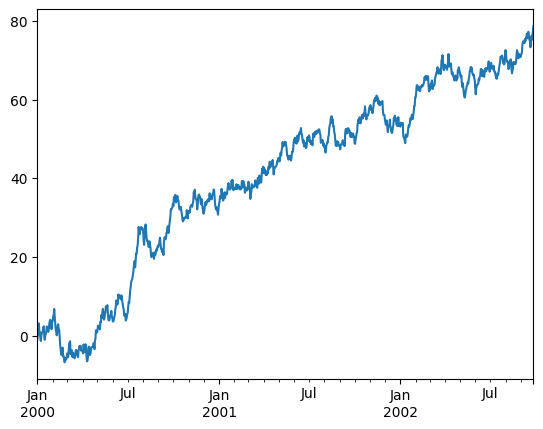

In [88]:
ts = pd.Series(np.random.randn(1000), index=pd.date_range("1/1/2000", periods=1000))

ts = ts.cumsum()

ts.plot();

<div class="admonition note">
<p class="admonition-title">Note</p>
<p>When using Jupyter, the plot will appear using <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.plot.html#pandas.Series.plot" title="pandas.Series.plot"><code>plot()</code></a>.  Otherwise use <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html">matplotlib.pyplot.show</a> to show it or
<a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html">matplotlib.pyplot.savefig</a> to write it to a file.</p>
</div>

<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html#pandas.DataFrame.plot" title="pandas.DataFrame.plot"><code>plot()</code></a> plots all columns:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell70"><span></span><span class="gp">In [129]: </span><span class="n">df</span> <span class="o">=</span> <span class="n">pd</span><span class="o">.</span><span class="n">DataFrame</span><span class="p">(</span>
<span class="gp">   .....: </span>    <span class="n">np</span><span class="o">.</span><span class="n">random</span><span class="o">.</span><span class="n">randn</span><span class="p">(</span><span class="mi">1000</span><span class="p">,</span> <span class="mi">4</span><span class="p">),</span> <span class="n">index</span><span class="o">=</span><span class="n">ts</span><span class="o">.</span><span class="n">index</span><span class="p">,</span> <span class="n">columns</span><span class="o">=</span><span class="p">[</span><span class="s2">"A"</span><span class="p">,</span> <span class="s2">"B"</span><span class="p">,</span> <span class="s2">"C"</span><span class="p">,</span> <span class="s2">"D"</span><span class="p">]</span>
<span class="gp">   .....: </span><span class="p">)</span>
<span class="gp">   .....: </span>

<span class="gp">In [130]: </span><span class="n">df</span> <span class="o">=</span> <span class="n">df</span><span class="o">.</span><span class="n">cumsum</span><span class="p">()</span>

<span class="gp">In [131]: </span><span class="n">plt</span><span class="o">.</span><span class="n">figure</span><span class="p">();</span>

<span class="gp">In [132]: </span><span class="n">df</span><span class="o">.</span><span class="n">plot</span><span class="p">();</span>

<span class="gp">In [133]: </span><span class="n">plt</span><span class="o">.</span><span class="n">legend</span><span class="p">(</span><span class="n">loc</span><span class="o">=</span><span class="s1">'best'</span><span class="p">);</span>
</pre>
</div>
</div>

# <h2>Importing and exporting data</h2>

<p>See the <a href="https://pandas.pydata.org/docs/user_guide/io.html#io">IO Tools</a> section.</p>

## <h3>CSV</h3>

<p><a href="https://pandas.pydata.org/docs/user_guide/io.html#io-store-in-csv">Writing to a csv file:</a> using <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html#pandas.DataFrame.to_csv" title="pandas.DataFrame.to_csv"><code>DataFrame.to_csv()</code></a></p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell71"><span></span><span class="gp">In [134]: </span><span class="n">df</span> <span class="o">=</span> <span class="n">pd</span><span class="o">.</span><span class="n">DataFrame</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">random</span><span class="o">.</span><span class="n">randint</span><span class="p">(</span><span class="mi">0</span><span class="p">,</span> <span class="mi">5</span><span class="p">,</span> <span class="p">(</span><span class="mi">10</span><span class="p">,</span> <span class="mi">5</span><span class="p">)))</span>

<span class="gp">In [135]: </span><span class="n">df</span><span class="o">.</span><span class="n">to_csv</span><span class="p">(</span><span class="s2">"foo.csv"</span><span class="p">)</span>
</pre>
</div>
</div>

<p><a href="https://pandas.pydata.org/docs/user_guide/io.html#io-read-csv-table">Reading from a csv file:></a> using <a href="https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html#pandas.read_csv" title="pandas.read_csv"><code>read_csv()</code></a></p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell72"><span></span><span class="gp">In [136]: </span><span class="n">pd</span><span class="o">.</span><span class="n">read_csv</span><span class="p">(</span><span class="s2">"foo.csv"</span><span class="p">)</span>
<span class="gh">Out[136]: </span>
   Unnamed: 0  0  1  2  3  4</span>
0           0  4  3  1  1  2</span>
1           1  1  0  2  3  2</span>
2           2  1  4  2  1  2</span>
3           3  0  4  0  2  2</span>
4           4  4  2  2  3  4</span>
5           5  4  0  4  3  1</span>
6           6  2  1  2  0  3</span>
7           7  4  0  4  4  4</span>
8           8  4  4  1  0  1</span>
9           9  0  4  3  0  3</span>
</pre>
</div>
</div>

## <h3>Parquet</h3>

<p>Writing to a Parquet file:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell73"><span></span><span class="gp">In [137]: </span><span class="n">df</span><span class="o">.</span><span class="n">to_parquet</span><span class="p">(</span><span class="s2">"foo.parquet"</span><span class="p">)</span>
</pre>
</div>
</div>

<p>Reading from a Parquet file Store using <a href="https://pandas.pydata.org/docs/reference/api/pandas.read_parquet.html#pandas.read_parquet" title="pandas.read_parquet"><code>read_parquet()</code></a>:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell74"><span></span><span class="gp">In [138]: </span><span class="n">pd</span><span class="o">.</span><span class="n">read_parquet</span><span class="p">(</span><span class="s2">"foo.parquet"</span><span class="p">)</span>
<span class="gh">Out[138]: </span>
   0  1  2  3  4</span>
0  4  3  1  1  2</span>
1  1  0  2  3  2</span>
2  1  4  2  1  2</span>
3  0  4  0  2  2</span>
4  4  2  2  3  4</span>
5  4  0  4  3  1</span>
6  2  1  2  0  3</span>
7  4  0  4  4  4</span>
8  4  4  1  0  1</span>
9  0  4  3  0  3</span>
</pre>
</div>
</div>

## <h3>Excel</h3>

<p>Reading and writing to <a href="https://pandas.pydata.org/docs/user_guide/io.html#io-excel">Excel</span></a>.</p>

<p>Writing to an excel file using <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_excel.html#pandas.DataFrame.to_excel" title="pandas.DataFrame.to_excel"><code>DataFrame.to_excel()</code></a>:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell75"><span></span><span class="gp">In [139]: </span><span class="n">df</span><span class="o">.</span><span class="n">to_excel</span><span class="p">(</span><span class="s2">"foo.xlsx"</span><span class="p">,</span> <span class="n">sheet_name</span><span class="o">=</span><span class="s2">"Sheet1"</span><span class="p">)</span>
</pre>
</div>
</div>

<p>Reading from an excel file using <a href="https://pandas.pydata.org/docs/reference/api/pandas.read_excel.html#pandas.read_excel" title="pandas.read_excel"><code>read_excel()</code></a>:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell76"><span></span><span class="gp">In [140]: </span><span class="n">pd</span><span class="o">.</span><span class="n">read_excel</span><span class="p">(</span><span class="s2">"foo.xlsx"</span><span class="p">,</span> <span class="s2">"Sheet1"</span><span class="p">,</span> <span class="n">index_col</span><span class="o">=</span><span class="kc">None</span><span class="p">,</span> <span class="n">na_values</span><span class="o">=</span><span class="p">[</span><span class="s2">"NA"</span><span class="p">])</span>
<span class="gh">Out[140]: </span>
   Unnamed: 0  0  1  2  3  4</span>
0           0  4  3  1  1  2</span>
1           1  1  0  2  3  2</span>
2           2  1  4  2  1  2</span>
3           3  0  4  0  2  2</span>
4           4  4  2  2  3  4</span>
5           5  4  0  4  3  1</span>
6           6  2  1  2  0  3</span>
7           7  4  0  4  4  4</span>
8           8  4  4  1  0  1</span>
9           9  0  4  3  0  3</span>
</pre>
</div>
</div>

# <h2>Gotchas</h2>

<p>If you are attempting to perform a boolean operation on a <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.html#pandas.Series"><code>Series</code></a> or <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> you might see an exception like:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell77"><span></span><span class="gp">In [141]: </span><span class="k">if</span> <span class="n">pd</span><span class="o">.</span><span class="n">Series</span><span class="p">([</span><span class="kc">False</span><span class="p">,</span> <span class="kc">True</span><span class="p">,</span> <span class="kc">False</span><span class="p">]):</span>
<span class="gp">   .....: </span>     <span class="nb">print</span><span class="p">(</span><span class="s2">"I was true"</span><span class="p">)</span>
<span class="gp">   .....: </span>
<span class="gt">---------------------------------------------------------------------------</span>
<span class="ne">ValueError</span><span class="g g-Whitespace">                                </span>Traceback (most recent call last)
<span class="nn">&lt;ipython-input-141-b27eb9c1dfc0&gt;</span> in <span class="ni">?</span><span class="nt">()</span>
<span class="ne">----&gt; </span><span class="mi">1</span> <span class="k">if</span> <span class="n">pd</span><span class="o">.</span><span class="n">Series</span><span class="p">([</span><span class="kc">False</span><span class="p">,</span> <span class="kc">True</span><span class="p">,</span> <span class="kc">False</span><span class="p">]):</span>
<span class="g g-Whitespace">      </span><span class="mi">2</span>      <span class="nb">print</span><span class="p">(</span><span class="s2">"I was true"</span><span class="p">)</span>

<span class="nn">~/work/pandas/pandas/pandas/core/generic.py</span> in <span class="ni">?</span><span class="nt">(self)</span>
<span class="g g-Whitespace">   </span><span class="mi">1575</span>     <span class="nd">@final</span>
<span class="g g-Whitespace">   </span><span class="mi">1576</span>     <span class="k">def</span><span class="w"> </span><span class="nf">__nonzero__</span><span class="p">(</span><span class="bp">self</span><span class="p">)</span> <span class="o">-&gt;</span> <span class="n">NoReturn</span><span class="p">:</span>
<span class="ne">-&gt; </span><span class="mi">1577</span>         <span class="k">raise</span> <span class="ne">ValueError</span><span class="p">(</span>
<span class="g g-Whitespace">   </span><span class="mi">1578</span>             <span class="sa">f</span><span class="s2">"The truth value of a </span><span class="si">{</span><span class="nb">type</span><span class="p">(</span><span class="bp">self</span><span class="p">)</span><span class="o">.</span><span class="vm">__name__</span><span class="si">}</span><span class="s2"> is ambiguous. "</span>
<span class="g g-Whitespace">   </span><span class="mi">1579</span>             <span class="s2">"Use a.empty, a.bool(), a.item(), a.any() or a.all()."</span>
<span class="g g-Whitespace">   </span><span class="mi">1580</span>         <span class="p">)</span>

<span class="ne">ValueError</span>: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
</pre>
</div>
</div>

<p>See <a href="https://pandas.pydata.org/docs/user_guide/basics.html#basics-compare">Comparisons</a> and <a href="https://pandas.pydata.org/docs/user_guide/gotchas.html#gotchas">Gotchas</a> for an explanation and what to do.</p>